In [1]:
import os
import sys
import torch
import numpy as np
from scipy import stats

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))

from models.source.pnncritic_vec import HybridActor
from environment.config import markov_config
from stable_baselines3 import SAC

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("MPS is available. Using Apple Silicon GPU.")
elif torch.backends.mps.is_built():
    print("MPS is built, but not available (likely an older macOS).")
    device = torch.device("cpu")
else:
    print("MPS not available. Using CPU.")
    device = torch.device("cpu")

MPS is built, but not available (likely an older macOS).


In [2]:
# PNNcritic2 copy 3

checkpoint = torch.load("saved_models/pnncritic.pth", map_location=device)

# Reconstruct the Actor using the saved dimensions
actor = HybridActor(
    state_dim=checkpoint["state_dim"],
    action_dim=checkpoint["action_dim"],
    hidden_dim=checkpoint["hidden_dim"],
    T=checkpoint["T"]
).to(device)

# Load the weights into the Actor
actor.load_state_dict(checkpoint["actor_state_dict"])

# Set to evaluation mode (turns off gradients and exploration)
actor.eval()




HybridActor(
  (trunk): Sequential(
    (0): Linear(in_features=36, out_features=64, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ELU(alpha=1.0)
  )
  (action_head): Linear(in_features=64, out_features=6, bias=True)
)

In [3]:
sac_model = SAC.load("saved_models/sacdp.zip")

In [12]:
from models.source.sac import evaluate_sac_agent
from models.source.pnncritic import evaluate_pnncritic_agent

In [14]:
import matplotlib.pyplot as plt
def compare_allocations(actor_pnn, model_sac, markov_config, K, seed=42):
    """
    Evaluates both agents on the same seed and plots their allocations side-by-side.
    """
    # Run Evaluations
    pnn_acts, pnn_wealth, pnn_nav, pnn_score = evaluate_pnncritic_agent(
        actor_pnn, markov_config, K, seed=seed, verbose=False
    )
    
    sac_acts, sac_wealth, sac_nav, sac_score = evaluate_sac_agent(
        model_sac, markov_config, K, seed=seed, verbose=False
    )
    markov_config["bond_configs"] = {'bond_type': '1M_Bill', 'nominal_value': 100,
     'maturity_months': 1, 'coupon_dates': [1]},
    {'bond_type': '3M_Bill', 'nominal_value': 100,
     'maturity_months': 3, 'coupon_dates': [3]},
    {'bond_type': '6M_Bill', 'nominal_value': 100,
     'maturity_months': 6, 'coupon_dates': [6]},
    {'bond_type': '12M_6Months', 'nominal_value': 100,
     'maturity_months': 12, 'coupon_dates': [6, 12]},
    
    # Setup Data
    T = markov_config["T"]
    month_labels = [f"Mo {t}" for t in range(T)] 
    time_steps = np.arange(T)
    
    bond_labels = [cfg['bond_type'] for cfg in markov_config["bond_configs"]] + ["HOLD_CASH"]
    num_assets = K + 1

    print(f"--- Evaluation Results (Seed: {seed}) ---")
    print(f"SAC Terminal NAV: {sac_nav:.2f} € | Utility: {sac_score:.2f}")
    print(f"PNN Terminal NAV: {pnn_nav:.2f} € | Utility: {pnn_score:.2f}\n")

    bar_width = 0.35

    # ==========================================
    # Plot 1: Subplots per Asset (Grouped Bars)
    # ==========================================
    fig1, axes = plt.subplots(num_assets, 1, figsize=(16, 3.5 * num_assets), sharex=True)
    if num_assets == 1:
        axes = [axes]

    for i, label in enumerate(bond_labels):
        ax = axes[i]
        sac_alloc = sac_acts[:, i]
        pnn_alloc = pnn_acts[:, i]

        # Plot side-by-side
        bars_sac = ax.bar(time_steps - bar_width/2, sac_alloc, width=bar_width, 
                          label='SAC', color='#1f77b4', edgecolor='black', linewidth=0.5)
        bars_pnn = ax.bar(time_steps + bar_width/2, pnn_alloc, width=bar_width, 
                          label='Our model', color='#ff7f0e', edgecolor='black', linewidth=0.5)

        ax.set_title(f"Allocation: {label}", fontsize=12, fontweight='bold')
        ax.set_ylabel("Euros (€)")
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.legend(loc='upper right')
        
        # Expand Y-axis slightly for visual clarity
        ax.set_ylim(0, max(max(sac_alloc), max(pnn_alloc)) * 1.25 + 1e-9)

    axes[-1].set_xlabel("Timeline", fontsize=12)
    axes[-1].set_xticks(time_steps)
    axes[-1].set_xticklabels(month_labels, rotation=45)
    
    fig1.suptitle(f"SAC vs Our Model: Asset-by-Asset Allocation (Seed {seed})", fontsize=16)
    fig1.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

    # ==========================================
    # Plot 2: Full Portfolio Paired Stacked Bars
    # ==========================================
    fig2, ax2 = plt.subplots(figsize=(18, 9))
    colors = plt.cm.tab20(np.linspace(0, 1, num_assets))
    
    bottom_sac = np.zeros(T)
    bottom_pnn = np.zeros(T)

    for i, label in enumerate(bond_labels):
        sac_vals = sac_acts[:, i]
        pnn_vals = pnn_acts[:, i]
        
        # SAC stacked segments
        bars_sac = ax2.bar(time_steps - bar_width/2, sac_vals, width=bar_width, 
                           bottom=bottom_sac, color=colors[i], edgecolor='white')
        # PNN stacked segments
        bars_pnn = ax2.bar(time_steps + bar_width/2, pnn_vals, width=bar_width, 
                           bottom=bottom_pnn, color=colors[i], edgecolor='white')
        
        bottom_sac += sac_vals
        bottom_pnn += pnn_vals

    # Create custom legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors[i], edgecolor='white', label=label) 
                       for i, label in enumerate(bond_labels)]
    legend_elements.append(Patch(facecolor='white', edgecolor='black', label='Left Bar = SAC'))
    legend_elements.append(Patch(facecolor='white', edgecolor='black', label='Right Bar = Our Model'))

    ax2.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))
    ax2.set_title(f"Portfolio Allocation Over Time (SAC vs Our Model)", fontsize=16)
    ax2.set_xlabel("Timeline", fontsize=12)
    ax2.set_ylabel("Total Invested Wealth (€)", fontsize=12)
    
    ax2.set_xticks(time_steps)
    ax2.set_xticklabels(month_labels, rotation=45)
    ax2.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()
    
    

--- Evaluation Results (Seed: 125) ---
SAC Terminal NAV: 722.98 € | Utility: -0.49
PNN Terminal NAV: 728.82 € | Utility: -0.48



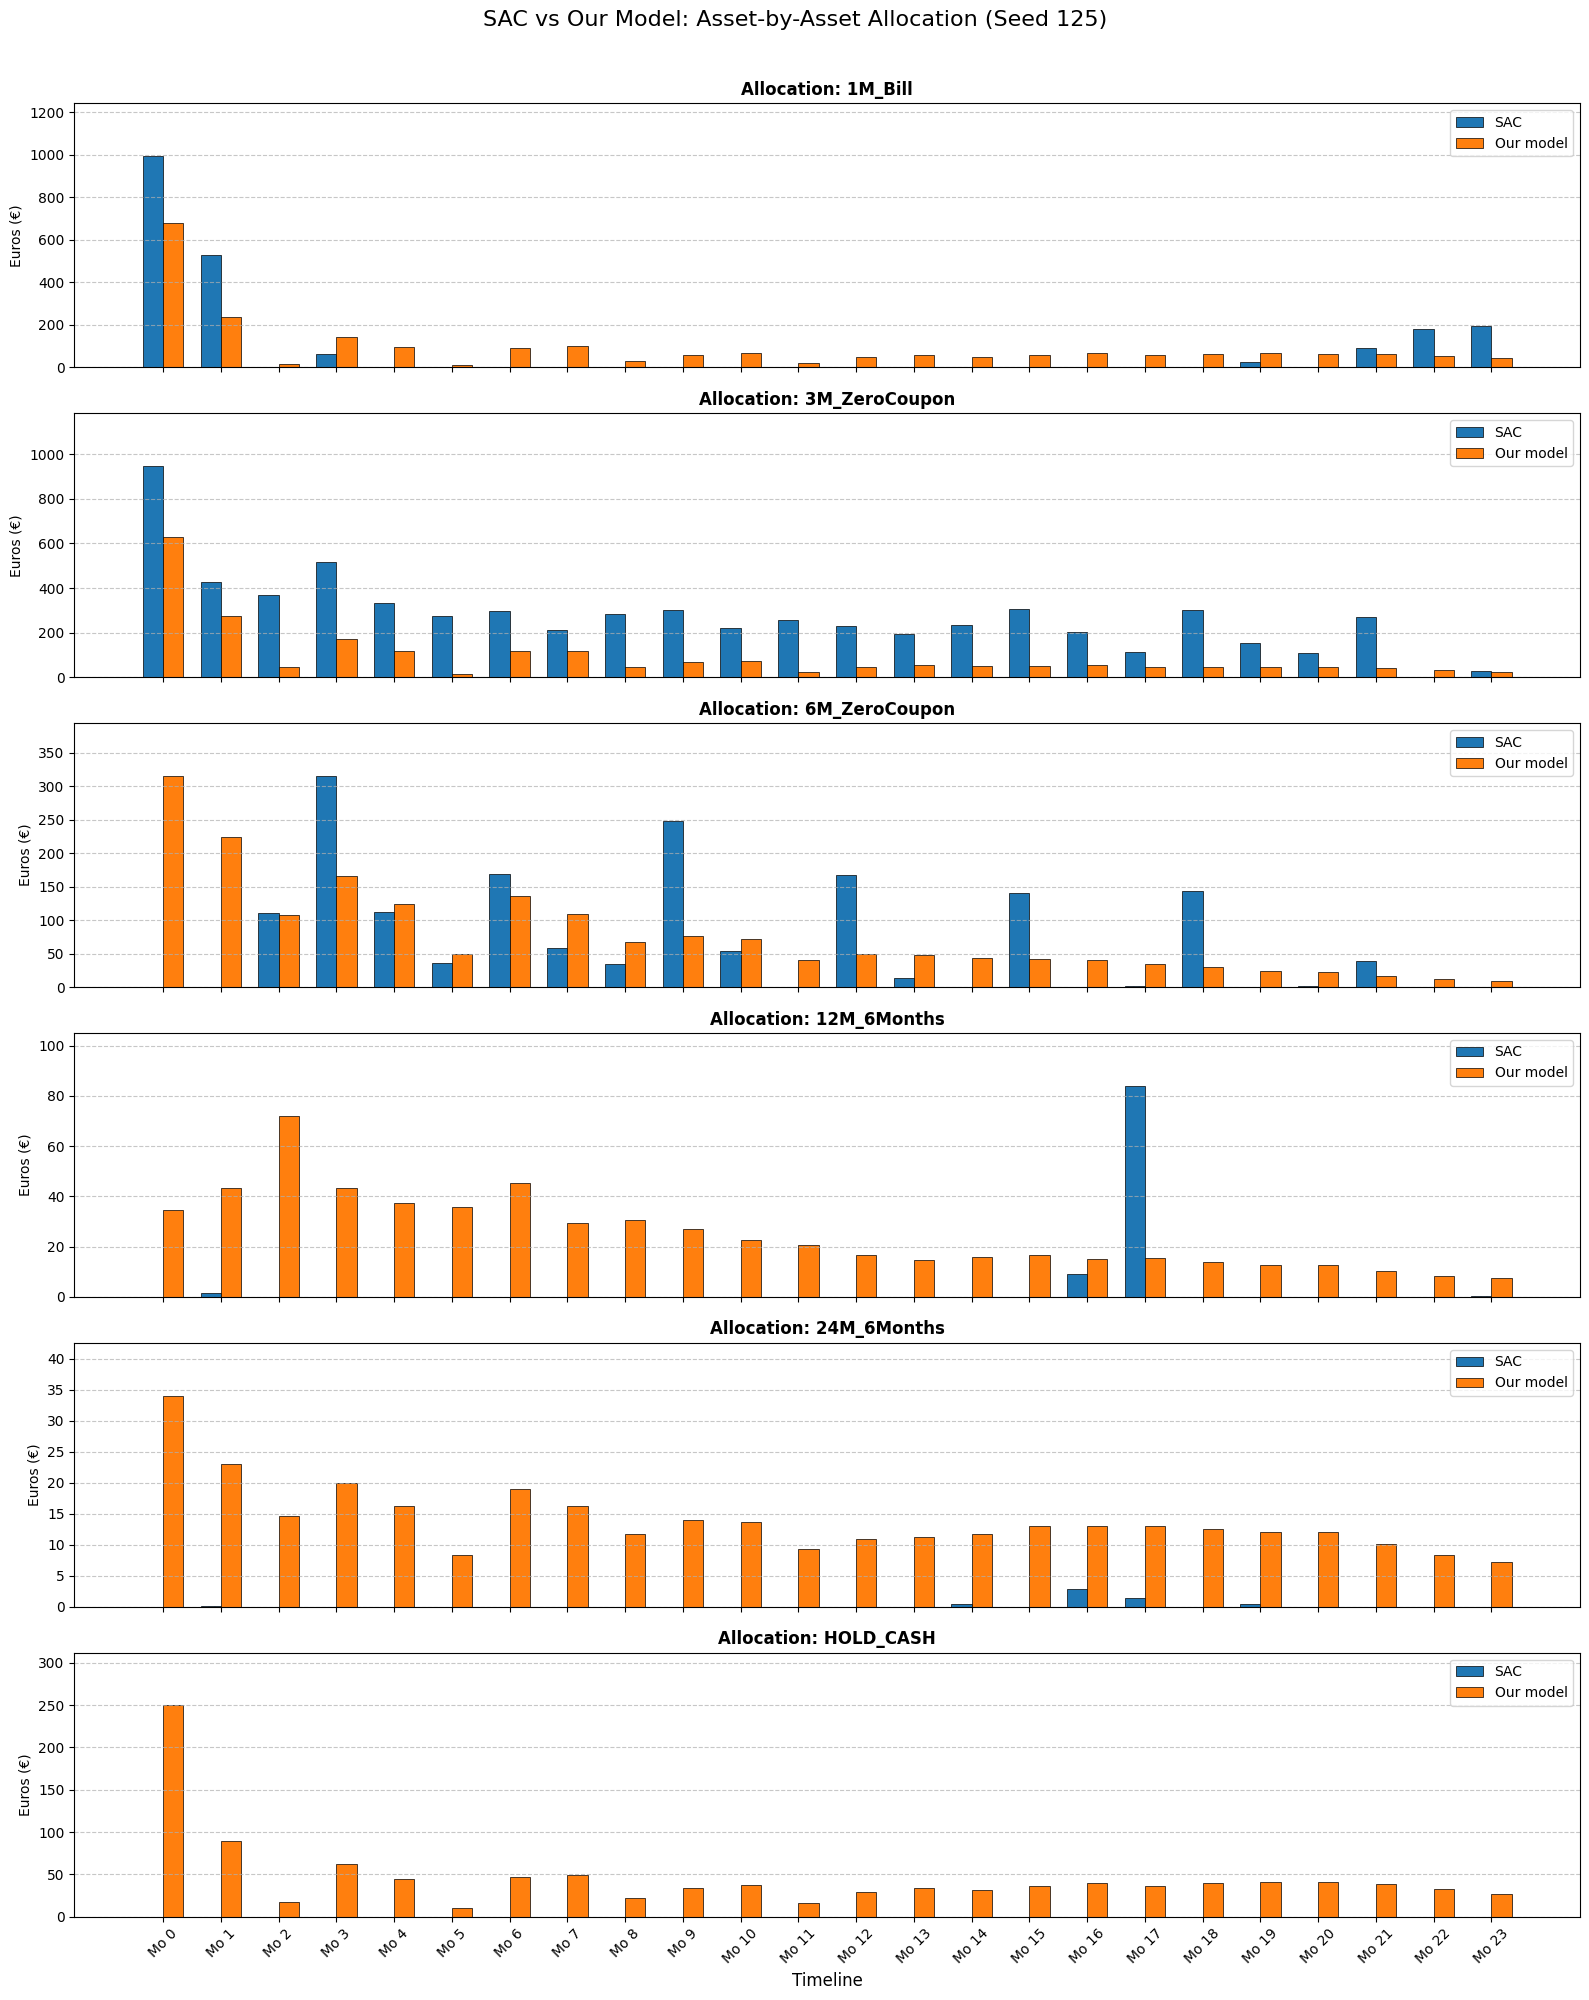

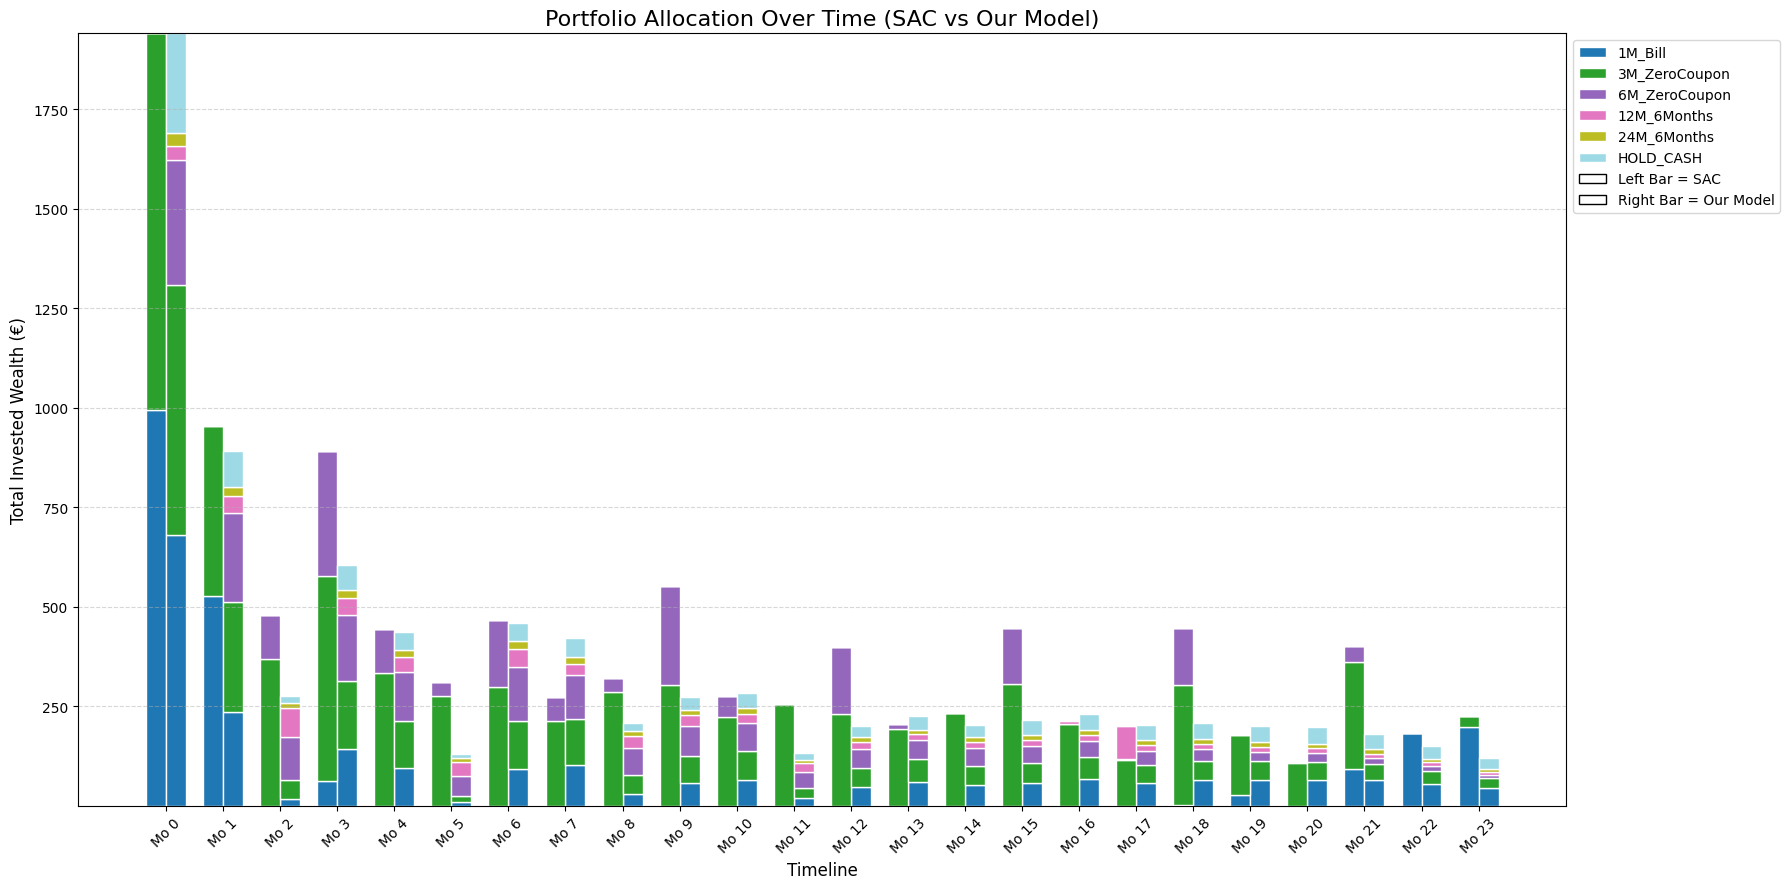

In [ ]:

compare_allocations(actor, sac_model, markov_config, K=5, seed=125)

In [5]:
def collect_terminal_navs(evaluator, model, markov_config, K, seeds,
                          nav_index=2, log_every=5000):
    navs = np.empty(len(seeds), dtype=np.float64)
    for i, s in enumerate(seeds):
        out = evaluator(model, markov_config, K, seed=int(s), verbose=False)
        navs[i] = float(out[nav_index])          # terminal_nav
        if log_every and (i + 1) % log_every == 0:
            print(f"  ... {i + 1:,}/{len(seeds):,}  (NAV current avg: {navs[:i+1].mean():.2f})")
    return navs

In [6]:
from models.source.sac import evaluate_sac_agent
from models.source.pnncritic_vec import evaluate_pnncritic_agent
N_SEEDS = 100_000
seeds = np.arange(N_SEEDS) 


In [7]:
print("Collecting NAV (SAC)...")
nav_sac = collect_terminal_navs(evaluate_sac_agent, sac_model, markov_config, 5, seeds)
 


  ... 5,000/100,000  (NAV current avg: 695.85)
  ... 10,000/100,000  (NAV current avg: 695.50)
  ... 15,000/100,000  (NAV current avg: 695.58)
  ... 20,000/100,000  (NAV current avg: 695.68)
  ... 25,000/100,000  (NAV current avg: 695.90)
  ... 30,000/100,000  (NAV current avg: 695.63)
  ... 35,000/100,000  (NAV current avg: 695.53)
  ... 40,000/100,000  (NAV current avg: 695.67)
  ... 45,000/100,000  (NAV current avg: 695.96)
  ... 50,000/100,000  (NAV current avg: 695.81)
  ... 55,000/100,000  (NAV current avg: 695.84)
  ... 60,000/100,000  (NAV current avg: 695.70)
  ... 65,000/100,000  (NAV current avg: 695.65)
  ... 70,000/100,000  (NAV current avg: 695.65)
  ... 75,000/100,000  (NAV current avg: 695.78)
  ... 80,000/100,000  (NAV current avg: 695.82)
  ... 85,000/100,000  (NAV current avg: 695.73)
  ... 90,000/100,000  (NAV current avg: 695.73)
  ... 95,000/100,000  (NAV current avg: 695.75)
  ... 100,000/100,000  (NAV current avg: 695.78)


In [8]:
print("Collecting NAV (our proposal)...")
nav_ours = collect_terminal_navs(evaluate_pnncritic_agent, actor, markov_config, 5, seeds)


  ... 5,000/100,000  (NAV current avg: 702.85)
  ... 10,000/100,000  (NAV current avg: 702.55)
  ... 15,000/100,000  (NAV current avg: 702.47)
  ... 20,000/100,000  (NAV current avg: 702.57)
  ... 25,000/100,000  (NAV current avg: 702.71)
  ... 30,000/100,000  (NAV current avg: 702.45)
  ... 35,000/100,000  (NAV current avg: 702.36)
  ... 40,000/100,000  (NAV current avg: 702.48)
  ... 45,000/100,000  (NAV current avg: 702.76)
  ... 50,000/100,000  (NAV current avg: 702.61)
  ... 55,000/100,000  (NAV current avg: 702.64)
  ... 60,000/100,000  (NAV current avg: 702.53)
  ... 65,000/100,000  (NAV current avg: 702.47)
  ... 70,000/100,000  (NAV current avg: 702.49)
  ... 75,000/100,000  (NAV current avg: 702.62)
  ... 80,000/100,000  (NAV current avg: 702.67)
  ... 85,000/100,000  (NAV current avg: 702.59)
  ... 90,000/100,000  (NAV current avg: 702.56)
  ... 95,000/100,000  (NAV current avg: 702.58)
  ... 100,000/100,000  (NAV current avg: 702.62)


In [9]:
np.save("test-diff/nav_sac.npy", nav_sac)
np.save("test-diff/nav_ours.npy", nav_ours)
 
print(f"  SAC  : mean = {nav_sac.mean():.2f},  bankrupt = {(nav_sac < 0).mean()*100:.3f}%")
print(f"  Ours : mean = {nav_ours.mean():.2f}, bankrupt = {(nav_ours < 0).mean()*100:.3f}%")
 
corr = np.corrcoef(nav_ours, nav_sac)[0, 1]
print(f"  Correlation NAV(ours, SAC) = {corr:.4f}")
 

  SAC  : mean = 695.78,  bankrupt = 0.002%
  Ours : mean = 702.62, bankrupt = 0.040%
  Correlation NAV(ours, SAC) = 0.9913


In [10]:
nav_ours = np.load("test-diff/nav_ours.npy")
nav_sac  = np.load("test-diff/nav_sac.npy")

assert nav_ours.shape == nav_sac.shape, "Arrays must have the same length and be aligned by seed"
N = len(nav_ours)

ALPHA = 0.05            # level for 95% CI
ALPHA_TAIL = 0.05       # tail for VaR/CVaR (5%)
N_BOOT = 10_000         # bootstrap repetitions
RNG = np.random.default_rng(0)


def var_lower(x, q=ALPHA_TAIL):
    return np.percentile(x, 100 * q)

def cvar_lower(x, q=ALPHA_TAIL):
    thr = np.percentile(x, 100 * q)
    return x[x <= thr].mean()

# PAIRED BOOTSTRAP
def paired_bootstrap_ci(stat_fn, a, b, n_boot=N_BOOT, alpha=ALPHA, rng=RNG):
    """Bootstrap CI (percentile) on the difference stat_fn(a) - stat_fn(b)."""
    n = len(a)
    diffs = np.empty(n_boot)
    for k in range(n_boot):
        idx = rng.integers(0, n, n)          # same indices for a and b -> paired
        diffs[k] = stat_fn(a[idx]) - stat_fn(b[idx])
    lo, hi = np.percentile(diffs, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    point = stat_fn(a) - stat_fn(b)
    return point, lo, hi


d = nav_ours - nav_sac
mean_diff = d.mean()
sem_diff = d.std(ddof=1) / np.sqrt(N)
ci_lo = mean_diff - stats.norm.ppf(1 - ALPHA / 2) * sem_diff
ci_hi = mean_diff + stats.norm.ppf(1 - ALPHA / 2) * sem_diff

# Paired t-test
t_stat, p_t = stats.ttest_rel(nav_ours, nav_sac)

# Wilcoxon signed-rank
w_stat, p_w = stats.wilcoxon(nav_ours, nav_sac)

# Effect size: Cohen's d
cohens_d = mean_diff / d.std(ddof=1)

# Correlation between the two NAVs (shows why pairing matters)
corr = np.corrcoef(nav_ours, nav_sac)[0, 1]

print("=" * 70)
print(f"N = {N:,} seed  |  correlation NAV(ours, SAC) = {corr:.4f}")
print("  (high correlation -> the paired design greatly reduces variance)")
print("=" * 70)
print("\n--- NAV MEAN (paired difference: ours - SAC) ---")
print(f"  Mean ours          : {nav_ours.mean():.2f}  (SEM {nav_ours.std(ddof=1)/np.sqrt(N):.3f})")
print(f"  Mean SAC           : {nav_sac.mean():.2f}  (SEM {nav_sac.std(ddof=1)/np.sqrt(N):.3f})")
print(f"  Mean difference    : {mean_diff:.3f}")
print(f"  95% CI (paired)    : [{ci_lo:.3f}, {ci_hi:.3f}]")
print(f"  Paired t-test      : t = {t_stat:.2f},  p = {p_t:.2e}")
print(f"  Wilcoxon           : p = {p_w:.2e}")
print(f"  Cohen's d (paired) : {cohens_d:.4f}  (0.2=small, 0.5=medium, 0.8=large)")

# VaR AND CVaR (only bootstrap: they are quantiles, no t-test)
var_point, var_lo, var_hi = paired_bootstrap_ci(var_lower, nav_ours, nav_sac)
cvar_point, cvar_lo, cvar_hi = paired_bootstrap_ci(cvar_lower, nav_ours, nav_sac)

print("\n VaR(5%) and CVaR(5%) (difference ours - SAC, paired bootstrap)")
print(f"  VaR(5%)  ours={var_lower(nav_ours):.2f}  SAC={var_lower(nav_sac):.2f}")
print(f"    diff = {var_point:.3f},  95% CI = [{var_lo:.3f}, {var_hi:.3f}]")
print(f"  CVaR(5%) ours={cvar_lower(nav_ours):.2f}  SAC={cvar_lower(nav_sac):.2f}")
print(f"    diff = {cvar_point:.3f},  95% CI = [{cvar_lo:.3f}, {cvar_hi:.3f}]")

rel = mean_diff / nav_sac.mean() * 100
print(f"  Mean relative advantage of NAV : {rel:+.2f}% of SAC NAV")

N = 100,000 seed  |  correlation NAV(ours, SAC) = 0.9913
  (high correlation -> the paired design greatly reduces variance)

--- NAV MEAN (paired difference: ours - SAC) ---
  Mean ours          : 702.62  (SEM 0.343)
  Mean SAC           : 695.78  (SEM 0.335)
  Mean difference    : 6.837
  95% CI (paired)    : [6.748, 6.926]
  Paired t-test      : t = 151.12,  p = 0.00e+00
  Wilcoxon           : p = 0.00e+00
  Cohen's d (paired) : 0.4779  (0.2=small, 0.5=medium, 0.8=large)

 VaR(5%) and CVaR(5%) (difference ours - SAC, paired bootstrap)
  VaR(5%)  ours=526.78  SAC=521.02
    diff = 5.759,  95% CI = [5.498, 6.051]
  CVaR(5%) ours=478.31  SAC=478.20
    diff = 0.105,  95% CI = [-1.699, 1.774]
  Mean relative advantage of NAV : +0.98% of SAC NAV
